In [1]:
import skimage as ski
import numpy as np
import matplotlib.pyplot as plt

bild = ski.io.imread("ambassadors.jpg")


In [3]:
def bilinear_interpolate(img, x, y):
    """Bilineare Interpolation an Stelle (x, y) im Bild."""
    H, W = img.shape[:2]
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0 + 1, y0 + 1

    # Außerhalb des Bilds → 0
    if not (0 <= x0 < W and 0 <= x1 < W and 0 <= y0 < H and 0 <= y1 < H):
        return 0

    # Flächenanteile (diagonal gegenüberliegend, wie im Skript)
    A1 = (x1 - x) * (y1 - y)   # Gewicht für P(x0, y0)
    A2 = (x  - x0) * (y1 - y)  # Gewicht für P(x1, y0)
    A3 = (x1 - x) * (y  - y0)  # Gewicht für P(x0, y1)
    A4 = (x  - x0) * (y  - y0) # Gewicht für P(x1, y1)

    p = (A1 * img[y0, x0].astype(float) +
         A2 * img[y0, x1].astype(float) +
         A3 * img[y1, x0].astype(float) +
         A4 * img[y1, x1].astype(float))

    return np.clip(p, 0, 255).astype(img.dtype)


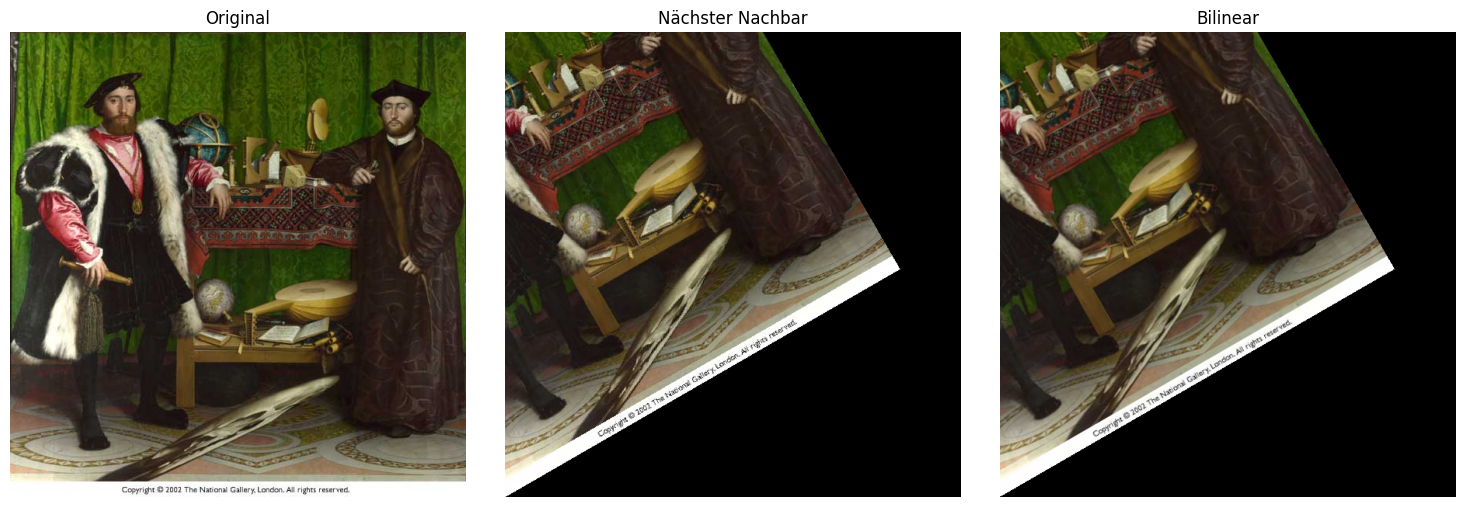

In [4]:
def affine_transform(A, a0, input_image, interpolation='nearest'):
    """
    Affine Transformation via indirekte Umbildung.

    Parameter:
        A            : (2,2) Transformationsmatrix
        a0           : (2,)  Verschiebungsvektor
        input_image  : numpy array, Shape (H,W) oder (H,W,C)
        interpolation: 'nearest' oder 'bilinear'

    Rückgabe:
        Transformiertes Bild, gleiche Shape wie input_image
    """
    H, W = input_image.shape[:2]
    is_color = input_image.ndim == 3
    output = np.zeros_like(input_image)

    A_inv = np.linalg.inv(A)

    # ── Alle Ziel-Koordinaten auf einmal erzeugen (vektorisiert) ────────────
    y_img, x_img = np.mgrid[0:H, 0:W]          # je Shape (H, W)

    # Bild-KS → Math-KS: y-Achse flippen
    x_math = x_img.astype(float)
    y_math = (H - 1 - y_img).astype(float)

    # Koordinaten als (2, H*W)-Matrix stapeln
    coords_prime = np.stack([x_math.ravel(), y_math.ravel()])  # (2, H*W)

    # Inverse Transformation: x_src = A⁻¹ · (x' - a0)
    coords_src = A_inv @ (coords_prime - a0[:, np.newaxis])    # (2, H*W)

    # Math-KS → Bild-KS zurückflipppen
    x_src = coords_src[0].reshape(H, W)
    y_src = (H - 1 - coords_src[1]).reshape(H, W)

    # ── Pixel auslesen ───────────────────────────────────────────────────────
    if interpolation == 'nearest':
        xi = np.round(x_src).astype(int)
        yi = np.round(y_src).astype(int)

        # Maske: nur Pixel innerhalb des Bilds
        valid = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
        output[valid] = input_image[yi[valid], xi[valid]]

    elif interpolation == 'bilinear':
        # Bilinear muss leider pixelweise laufen (oder komplex vektorisiert)
        for y in range(H):
            for x in range(W):
                output[y, x] = bilinear_interpolate(
                    input_image, x_src[y, x], y_src[y, x]
                )

    return output


# ── Transformation definieren ────────────────────────────────────────────────

# Beispiel 1: Rotation um 30°
theta = np.radians(30)
A_rot = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])
a0 = np.array([0.0, 0.0])

# Beispiel 2: Skalierung
# A_scale = np.array([[1.5, 0], [0, 1.5]])

# Beispiel 3: Scherung
# A_shear = np.array([[1, 0.3], [0, 1]])


result_nn = affine_transform(A_rot, a0, bild, interpolation='nearest')
result_bl = affine_transform(A_rot, a0, bild, interpolation='bilinear')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(bild);         axes[0].set_title("Original")
axes[1].imshow(result_nn);    axes[1].set_title("Nächster Nachbar")
axes[2].imshow(result_bl);    axes[2].set_title("Bilinear")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
